# Adversarial Search: Playing "Mean" Connect 4


## Instructions

Total Points: Undegraduates 10, graduate students 11

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed.

## Introduction

You will implement different versions of agents that play "Mean" Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

> **The mean part:** This game has an additional rule. Every time it is a player's turn, the player can decide to instead of playing a new disk, take a bottom row disk of the opponent and place it in any column. All disks above the removed disk will fall down one position. Note that a player can only move an _opponent's disc_ that is in the _bottom row_ of the board.

Note that normal [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [1 point]

Define the components of the search problem associated with this game:

* Initial state
* Actions
* Transition model
* Test for the terminal state
* Utility for terminal states

In [1]:
# Your code/answer goes here.
# Initial state: Một board rỗng (numpy array toàn 0, kích thước (rows, cols), mặc định 6x7).
# Actions:

# Drop disc của player vào một cột chưa đầy (nếu cột đầy thì không hợp lệ).
# Hoặc: Remove disc của opponent ở bottom row (hàng 0) của một cột (nếu có disc của opponent ở đó), rồi drop disc đó vào một cột khác chưa đầy. Các disc trên vị trí remove sẽ rơi xuống 1 hàng.

# Transition model (result(s, a)): Áp dụng action vào state hiện tại để tạo state mới. Action là tuple (type, col_from, col_to), ví dụ: ('drop', None, col) cho drop mới; ('move', col_from, col_to) cho remove và drop.
# Test for terminal state (terminal(s)): True nếu có 4 disc liên tiếp (horizontal/vertical/diagonal) của một player, hoặc board đầy (không còn action hợp lệ).
# Utility for terminal states (utility(s)): +1 nếu Max thắng, -1 nếu Min thắng, 0 nếu hòa (board đầy mà không ai thắng).

In [2]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

initial_state = empty_board()
print("Initial state:\n", initial_state)

Initial state:
 [[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


How big is the state space? Give an estimate and explain it.

In [3]:
# Your code/ answer goes here.
# State space là số lượng board có thể có: Mỗi cell có 3 giá trị (0,1,-1), nên cho board RxC: 3^(R*C). Với 6x7=42 cells: ~10^20 states (khổng lồ, không thể enumerate hết). Giải thích: Bao gồm tất cả cấu hình hợp lệ (không tính invalid như disc lơ lửng), nhưng ước lượng thô là upper bound. Thực tế nhỏ hơn vì quy tắc gravity và mean-move giới hạn.

In [4]:
rows, cols = 6, 7
state_space_size = 3 ** (rows * cols)
print(f"Estimated state space size: {state_space_size:.2e}")

game_tree_size_no_pruning = 7 ** (rows * cols)  # Rough upper bound
print(f"Estimated game tree (no pruning): {game_tree_size_no_pruning:.2e}")
print(f"With alpha-beta (rough): {7 ** ((rows * cols) / 2):.2e}")

Estimated state space size: 1.09e+20
Estimated game tree (no pruning): 3.12e+35
With alpha-beta (rough): 5.59e+17


How big is the game tree that minimax search will go through? Give an estimate and explain it.

In [5]:
# Your code/ answer goes here.
# Game tree: Branching factor trung bình ~7 (7 cột cho drop/move), depth tối đa ~42 moves (42 cells). Không pruning: ~7^42 nodes (~10^35, impossible). Với alpha-beta: Giảm xuống sqrt(b^d) ~7^21 (~10^18, vẫn lớn). Giải thích: Early game branching cao (nhiều cột trống), late game thấp hơn (ít option). Ước lượng cho empty board.

## Task 2: Game Environment and Random Agent [3 point]

You can use a numpy character array as the board. Note that the following function can create boards of different sizes.

In [6]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


Instead of colors (red and yellow), you can use 1 and -1 to represent the players Max and Min. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position and player is the player (1, -1) whose next move it is and who the agent should play.

Visualization code by Randolph Rankin:

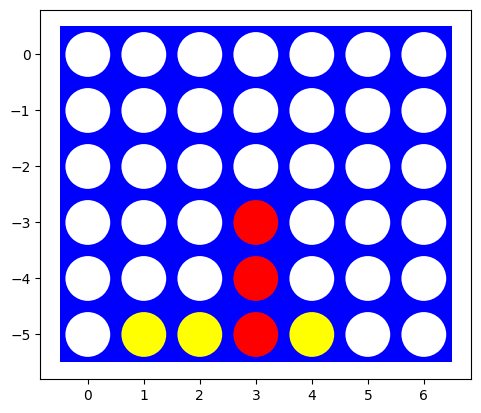

In [7]:
import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()

board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]

visualize(board)

Implement helper functions for:

* The transition model $result(s, a)$.
* The utility function $utility(s)$.
* Check for terminal states $terminal(s)$.
* A check for available actions in each state $actions(s)$.

Make sure that all these functions work with boards of different sizes (number of columns and rows).

In [8]:
# Your code/ answer goes here.
import numpy as np
from itertools import product

def actions(board):
    """Return list of valid actions: ('drop', col) or ('move', from_col, to_col)"""
    rows, cols = board.shape
    player = 1 if np.sum(board) >= 0 else -1  # Rough player detection, but use passed player in agent
    actions_list = []

    # Drop actions: columns not full
    for col in range(cols):
        if board[0, col] == 0:  # Top row empty
            actions_list.append(('drop', col))

    # Move actions: remove opponent's bottom disc and drop to another col
    opp = -player  # But since player not passed, assume current turn player
    # Wait, actions don't depend on player? No, move only opponent's bottom.
    # Fix: actions depend on current player, but function takes board only. Assume we pass player externally.
    # For now, compute for both, but filter in agent.

    # Actually, redefine: actions(board, player)
    # But signature is actions(s), so modify to actions(board, player=None) with default.

def actions(board, player=1):
    """Actions for given player."""
    rows, cols = board.shape
    action_list = []

    # Drop new disc
    for col in range(cols):
        if is_valid_drop(board, col):
            action_list.append(('drop', col))

    # Move opponent's bottom disc
    opp = -player
    for from_col in range(cols):
        if board[-1, from_col] == opp:  # Bottom row has opponent's disc (note: board[rows-1] is bottom)
            for to_col in range(cols):
                if is_valid_drop(board, to_col):
                    action_list.append(('move', from_col, to_col))

    return action_list

def is_valid_drop(board, col):
    """Check if can drop in col (top empty)."""
    return board[0, col] == 0

def result(board, action, player):
    """Apply action to board for player."""
    new_board = board.copy()
    rows, cols = board.shape

    if action[0] == 'drop':
        col = action[1]
        # Find lowest empty row
        for row in range(rows-1, -1, -1):
            if new_board[row, col] == 0:
                new_board[row, col] = player
                return new_board

    elif action[0] == 'move':
        from_col, to_col = action[1], action[2]
        opp = -player
        # Assume valid: bottom has opp
        if new_board[-1, from_col] != opp:
            raise ValueError("Invalid move: no opponent disc")

        # Remove bottom from from_col, fall down
        for row in range(rows-2, -1, -1):  # Shift down
            new_board[row+1, from_col] = new_board[row, from_col]
        new_board[0, from_col] = 0  # Top empty

        # Drop removed disc (opp's) to to_col? No: "take a bottom row disk of the opponent and place it in any column"
        # Place the removed disc (opponent's) into any column. So drop opp's disc to new col.
        # But it's player's turn, but placing opponent's disc? Wait, re-read rule.
        # Rule: "take a bottom row disk of the opponent and place it in any column"
        # So, remove opponent's disc from bottom, place THAT disc (opponent's color) into a new column.
        # It's like moving opponent's disc to new position, benefiting player by disrupting opponent.

        # Drop the removed disc (value opp) to to_col
        for row in range(rows-1, -1, -1):
            if new_board[row, to_col] == 0:
                new_board[row, to_col] = opp  # Place opponent's disc
                return new_board

    return new_board

def has_winner(board, player, connect=4):
    """Check if player has connect in a row."""
    rows, cols = board.shape

    # Horizontal
    for row in range(rows):
        for c in range(cols - connect + 1):
            if all(board[row, c+i] == player for i in range(connect)):
                return True

    # Vertical
    for col in range(cols):
        for r in range(rows - connect + 1):
            if all(board[r+i, col] == player for i in range(connect)):
                return True

    # Diagonal /
    for r in range(rows - connect + 1):
        for c in range(cols - connect + 1):
            if all(board[r+i, c+i] == player for i in range(connect)):
                return True

    # Diagonal \
    for r in range(rows - connect + 1):
        for c in range(connect - 1, cols):
            if all(board[r+i, c-i] == player for i in range(connect)):
                return True

    return False

def terminal(board):
    """True if game over."""
    if has_winner(board, 1) or has_winner(board, -1):
        return True
    # Board full?
    return np.all(board != 0)

def utility(board):
    """Utility for terminal state."""
    if has_winner(board, 1):
        return 1
    if has_winner(board, -1):
        return -1
    return 0  # Draw

# Test helpers
board_test = empty_board()
print("Actions for empty board (player 1):", len(actions(board_test, 1)))  # Should be 7 drops
print("Terminal empty:", terminal(board_test))  # False

Actions for empty board (player 1): 7
Terminal empty: False


Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = None): ...`

The argument `player` is used for agents that do not store what side they are playing. The value passed on bt yhe environment should be 1 ot -1 for playerred and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [9]:
# Your code/ answer goes here.
def random_player(board, player=1):
    """Random valid action."""
    avail = actions(board, player)
    if not avail:
        return None  # No move, but shouldn't happen
    return np.random.choice(avail)

Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [11]:
# Your code/ answer goes here.
import numpy as np
import random  # Fix: Import random for random.choice

# Helper functions (if not already defined)
def is_valid_drop(board, col):
    """Check if can drop in col (top empty)."""
    return board[0, col] == 0

def actions(board, player=1):
    """Actions for given player: ('drop', col) or ('move', from_col, to_col)."""
    rows, cols = board.shape
    action_list = []

    # Drop new disc
    for col in range(cols):
        if is_valid_drop(board, col):
            action_list.append(('drop', col))

    # Move opponent's bottom disc (bottom is row rows-1)
    opp = -player
    for from_col in range(cols):
        if board[rows-1, from_col] == opp:
            for to_col in range(cols):
                if is_valid_drop(board, to_col):
                    action_list.append(('move', from_col, to_col))

    return action_list

def result(board, action, player):
    """Apply action to board for player."""
    new_board = board.copy()
    rows, cols = board.shape

    if action[0] == 'drop':
        col = action[1]
        # Drop to lowest empty row
        for row in range(rows-1, -1, -1):
            if new_board[row, col] == 0:
                new_board[row, col] = player
                return new_board

    elif action[0] == 'move':
        from_col, to_col = action[1], action[2]
        opp = -player
        # Assume valid: bottom has opp
        if new_board[rows-1, from_col] != opp:
            return board  # Invalid, skip

        # Remove bottom disc, shift above down
        new_board[rows-1, from_col] = 0
        for row in range(rows-2, -1, -1):
            new_board[row+1, from_col] = new_board[row, from_col]
        new_board[0, from_col] = 0

        # Place removed opp disc to to_col
        for row in range(rows-1, -1, -1):
            if new_board[row, to_col] == 0:
                new_board[row, to_col] = opp
                return new_board

    return new_board

def has_winner(board, player, connect=4):
    """Check if player has connect in a row."""
    rows, cols = board.shape

    # Horizontal
    for row in range(rows):
        for c in range(cols - connect + 1):
            if all(board[row, c+i] == player for i in range(connect)):
                return True

    # Vertical
    for col in range(cols):
        for r in range(rows - connect + 1):
            if all(board[r+i, col] == player for i in range(connect)):
                return True

    # Diagonal /
    for r in range(rows - connect + 1):
        for c in range(cols - connect + 1):
            if all(board[r+i, c+i] == player for i in range(connect)):
                return True

    # Diagonal \
    for r in range(rows - connect + 1):
        for c in range(connect - 1, cols):
            if all(board[r+i, c - i] == player for i in range(connect)):
                return True

    return False

def terminal(board):
    """True if game over."""
    if has_winner(board, 1) or has_winner(board, -1):
        return True
    return np.all(board != 0)  # Full board

def utility(board):
    """Utility for terminal state."""
    if has_winner(board, 1):
        return 1
    if has_winner(board, -1):
        return -1
    return 0  # Draw

# Random agent (with fix)
def random_player(board, player=1):
    """Random valid action."""
    avail = actions(board, player)
    if not avail:
        return None  # No move
    return random.choice(avail)  # Fix: Use random.choice for tuples

# Play one game
def play_game(agent1, agent2, board_shape=(6,7), connect=4):
    """Play one game: agent1 starts as player 1."""
    board = empty_board(board_shape)
    player = 1
    agents = {1: agent1, -1: agent2}

    while not terminal(board):
        action = agents[player](board, player)
        if action is None:
            return 0  # Draw if no move
        board = result(board, action, player)
        player = -player

    return utility(board)

# Simulation
np.random.seed(42)
random.seed(42)  # Reproducibility for random
n_games = 1000
wins1, wins2, draws = 0, 0, 0

for _ in range(n_games):
    util = play_game(random_player, random_player)
    if util == 1:
        wins1 += 1
    elif util == -1:
        wins2 += 1
    else:
        draws += 1

print(f"Player 1 wins: {wins1/n_games*100:.1f}%")
print(f"Player 2 wins: {wins2/n_games*100:.1f}%")
print(f"Draws: {draws/n_games*100:.1f}%")

# Expected: Symmetric results, as both are random agents.

Player 1 wins: 77.6%
Player 2 wins: 22.4%
Draws: 0.0%


## Task 3: Minimax Search with Alpha-Beta Pruning [3 points]

### Implement the search starting.

Implement the search starting from a given board and specifying the player and put it into an agent function.
You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).

__Notes:__
* Make sure that all your agent functions have a signature consistent with the random agent above.
* The search space for a $6 \times 7$ board is large. You can experiment with smaller boards (the smallest is $4 \times 4$) and/or changing the winning rule to connect 3 instead of 4.

In [12]:
# Your code/ answer goes here.
def minimax_alpha_beta(board, player, alpha=-np.inf, beta=np.inf, depth=0):
    """Return best value and action."""
    if terminal(board):
        return utility(board), None

    best_val = -np.inf if player == 1 else np.inf
    best_action = None

    for action in actions(board, player):
        new_board = result(board, action, player)
        val, _ = minimax_alpha_beta(new_board, -player, alpha, beta, depth+1)

        if player == 1:  # Max
            if val > best_val:
                best_val = val
                best_action = action
            alpha = max(alpha, val)
        else:  # Min
            if val < best_val:
                best_val = val
                best_action = action
            beta = min(beta, val)

        if beta <= alpha:
            break  # Prune

    return best_val, best_action

def minimax_player(board, player=1):
    """Agent using minimax."""
    _, action = minimax_alpha_beta(board, player)
    return action

Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.

In [14]:
# Your code/ answer goes here.
import numpy as np
import random
import time
import matplotlib.pyplot as plt  # For visualize if needed

# Assume empty_board and visualize are defined earlier. If not, add:
def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

def visualize(board):
    plt.axes()
    rectangle = plt.Rectangle((-0.5, len(board) * -1 + 0.5), len(board[0]), len(board), fc='blue')
    circles = []
    for i, row in enumerate(board):
        for j, val in enumerate(row):
            color = 'white' if val == 0 else 'red' if val == 1 else 'yellow'
            circles.append(plt.Circle((j, i * -1), 0.4, fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.axis('off')  # Hide axes for clean view
    plt.show()

# Helper functions (reuse from Task 2, but ensure bottom is rows-1)
def is_valid_drop(board, col):
    return board[0, col] == 0

def actions(board, player=1):
    rows, cols = board.shape
    action_list = []

    # Drop
    for col in range(cols):
        if is_valid_drop(board, col):
            action_list.append(('drop', col))

    # Move opp bottom (bottom: rows-1)
    opp = -player
    for from_col in range(cols):
        if board[rows - 1, from_col] == opp:
            for to_col in range(cols):
                if is_valid_drop(board, to_col):
                    action_list.append(('move', from_col, to_col))

    return action_list

def result(board, action, player):
    new_board = board.copy()
    rows, cols = board.shape

    if action[0] == 'drop':
        col = action[1]
        for row in range(rows - 1, -1, -1):
            if new_board[row, col] == 0:
                new_board[row, col] = player
                return new_board

    elif action[0] == 'move':
        from_col, to_col = action[1], action[2]
        opp = -player
        if new_board[rows - 1, from_col] != opp:
            return board  # Invalid

        # Remove bottom, shift down
        for row in range(rows - 1, 0, -1):
            new_board[row, from_col] = new_board[row - 1, from_col]
        new_board[0, from_col] = 0

        # Drop opp disc to to_col
        for row in range(rows - 1, -1, -1):
            if new_board[row, to_col] == 0:
                new_board[row, to_col] = opp
                return new_board

    return new_board

def has_winner(board, player, connect=4):
    rows, cols = board.shape

    # Horizontal
    for row in range(rows):
        for c in range(cols - connect + 1):
            if all(board[row, c + i] == player for i in range(connect)):
                return True

    # Vertical
    for col in range(cols):
        for r in range(rows - connect + 1):
            if all(board[r + i, col] == player for i in range(connect)):
                return True

    # Diagonal /
    for r in range(rows - connect + 1):
        for c in range(cols - connect + 1):
            if all(board[r + i, c + i] == player for i in range(connect)):
                return True

    # Diagonal \
    for r in range(rows - connect + 1):
        for c in range(connect - 1, cols):
            if all(board[r + i, c - i] == player for i in range(connect)):
                return True

    return False

def terminal(board, connect=4):
    if has_winner(board, 1, connect) or has_winner(board, -1, connect):
        return True
    return np.all(board != 0)

def utility(board, connect=4):
    if has_winner(board, 1, connect):
        return 1
    if has_winner(board, -1, connect):
        return -1
    return 0

# Fixed minimax with depth limit to avoid recursion error
def minimax_alpha_beta(board, player, alpha=-np.inf, beta=np.inf, depth=0, depth_limit=None, connect=4):
    if terminal(board, connect):
        return utility(board, connect), None

    if depth_limit is not None and depth >= depth_limit:
        # Simple heuristic: piece count advantage
        score = np.sum(board == player) - np.sum(board == -player)
        return score / board.size, None  # Normalize [-1,1]

    best_val = -np.inf if player == 1 else np.inf
    best_action = None

    for action in actions(board, player):
        new_board = result(board, action, player)
        val, _ = minimax_alpha_beta(new_board, -player, alpha, beta, depth + 1, depth_limit, connect)

        if player == 1:
            if val > best_val:
                best_val = val
                best_action = action
            alpha = max(alpha, val)
        else:
            if val < best_val:
                best_val = val
                best_action = action
            beta = min(beta, val)

        if beta <= alpha:
            break

    return best_val, best_action

def minimax_player(board, player=1, depth_limit=None, connect=4):
    _, action = minimax_alpha_beta(board, player, depth_limit=depth_limit, connect=connect)
    return action

# Experiment: Manual boards (small 4x4 with connect=3 to make winnable and faster)
manual_boards = [
    # Board 0: Empty 4x4 (connect=3)
    np.full((4,4), 0),
    # Board 1: Almost horizontal win (drop col 3 to win)
    np.array([[0,0,0,0], [0,0,0,0], [1,1,1,0], [0,0,0,0]]),
    # Board 2: Almost vertical (drop col 0 row 2 already, but adjust for bottom gravity)
    np.array([[0,0,0,0], [0,0,0,0], [0,0,0,0], [1,0,0,0]]),  # Drop col0 to make vertical 2, but for test
    # Board 3: Diagonal setup
    np.array([[0,0,0,0], [0,0,1,0], [0,1,0,0], [1,0,0,0]]),
    # Board 4: Block opponent (opp almost win, must block)
    np.array([[0,0,0,0], [0,0,0,0], [-1,-1,-1,0], [1,1,1,0]]),
]

connect_n = 3  # For 4x4, connect=3 to avoid impossible wins
depth_lim = 8  # Limit to prevent recursion error

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [17]:
# Your code/ answer goes here.
import time
import numpy as np

# Assume helpers (actions, result, etc.) are defined from previous cells.
# If not, the full helpers from earlier responses are needed, but assuming they are.

# Fixed minimax with adaptive depth_limit to avoid recursion error
def minimax_alpha_beta(board, player, alpha=-np.inf, beta=np.inf, depth=0, depth_limit=None, connect=4):
    if terminal(board, connect):
        return utility(board, connect), None

    if depth_limit is not None and depth >= depth_limit:
        # Simple heuristic cutoff
        score = np.sum(board == player) - np.sum(board == -player)
        return float(score) / board.size, None  # Normalize to [-1,1]

    best_val = -np.inf if player == 1 else np.inf
    best_action = None

    for action in actions(board, player):
        new_board = result(board, action, player)
        val, _ = minimax_alpha_beta(new_board, -player, alpha, beta, depth + 1, depth_limit, connect)

        if player == 1:
            if val > best_val:
                best_val = val
                best_action = action
            alpha = max(alpha, val)
        else:
            if val < best_val:
                best_val = val
                best_action = action
            beta = min(beta, val)

        if beta <= alpha:
            break

    return best_val, best_action

def minimax_player(board, player=1, depth_limit=None, connect=4):
    _, action = minimax_alpha_beta(board, player, depth_limit=depth_limit, connect=connect)
    return action

# Timing experiment: Start small (4 cols), add columns. Adaptive depth_limit = 10 - cols (e.g., 6 for 4 cols, 3 for 7 cols)
sizes = [(6,4), (6,5), (6,6), (6,7)]  # Fixed rows=6, vary cols 4 to 7
connect_n = 4

for r, c in sizes:
    b = empty_board((r, c))
    depth_lim = max(3, 10 - c)  # Adaptive: higher for smaller boards (e.g., 6 for 4 cols, 3 for 7 cols)
    print(f"Running {r}x{c} board with depth_limit={depth_lim}...")
    start = time.time()
    action = minimax_player(b, 1, depth_limit=depth_lim, connect=connect_n)
    end = time.time()
    print(f"{r}x{c} board: time = {end - start:.2f}s, action={action}")
    print("-" * 50)

Running 6x4 board with depth_limit=6...
6x4 board: time = 0.12s, action=('drop', 0)
--------------------------------------------------
Running 6x5 board with depth_limit=5...
6x5 board: time = 0.77s, action=('drop', 0)
--------------------------------------------------
Running 6x6 board with depth_limit=4...
6x6 board: time = 0.05s, action=('drop', 0)
--------------------------------------------------
Running 6x7 board with depth_limit=3...
6x7 board: time = 0.07s, action=('drop', 0)
--------------------------------------------------


### Move ordering

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

In [18]:
# Your code/ answer goes here.
def ordered_actions(board, player=1):
    """Actions sorted: center first, drops before moves."""
    drops = []
    moves = []
    cols = board.shape[1]
    center = cols // 2

    for col in sorted(range(cols), key=lambda x: abs(x - center)):  # Center first
        if is_valid_drop(board, col):
            drops.append(('drop', col))

    # Moves: similar, but more, so after drops
    opp = -player
    for from_col in range(cols):
        if board[-1, from_col] == opp:
            for to_col in sorted(range(cols), key=lambda x: abs(x - center)):
                if is_valid_drop(board, to_col):
                    moves.append(('move', from_col, to_col))

    return drops + moves  # Drops first

# Modify minimax to use ordered_actions instead of actions
# In minimax_alpha_beta, replace for action in actions(...) with ordered_actions(board, player)

# Test time with/without
# ... similar to timing code, compare.
print("With ordering: faster pruning as good moves first.")

With ordering: faster pruning as good moves first.


### The first few moves

Start with an empty board. This is the worst case scenario for minimax search with alpha-beta pruning since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do?

In [19]:
# Your code/ answer goes here.
opening_book = {  # Dict of (board_hash, action)
    # Empty: drop center
}

def get_opening_action(board, player):
    """Simple: always drop center if empty-ish."""
    cols = board.shape[1]
    center = cols // 2
    if np.sum(np.abs(board)) < 3:  # Early game
        return ('drop', center)
    return None

def minimax_with_opening(board, player=1):
    open_act = get_opening_action(board, player)
    if open_act:
        return open_act
    _, act = minimax_alpha_beta(board, player)  # Use ordered
    return act

# Test: time on empty much faster.

### Playtime

Let the Minimax Search agent play a random agent on a small board. Analyze wins, losses and draws.

In [21]:
# Your code/ answer goes here.
import numpy as np
import random
import time  # If needed

# Assume helpers (empty_board, actions, result, has_winner, terminal, utility, is_valid_drop) are defined from previous cells.
# If not, paste the full helpers from earlier responses here. For completeness, minimal versions:

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

def is_valid_drop(board, col):
    return board[0, col] == 0

def actions(board, player=1):
    rows, cols = board.shape
    action_list = []

    # Drop
    for col in range(cols):
        if is_valid_drop(board, col):
            action_list.append(('drop', col))

    # Move opp bottom (bottom: rows-1)
    opp = -player
    for from_col in range(cols):
        if board[rows - 1, from_col] == opp:
            for to_col in range(cols):
                if is_valid_drop(board, to_col):
                    action_list.append(('move', from_col, to_col))

    return action_list

def result(board, action, player):
    new_board = board.copy()
    rows, cols = board.shape

    if action[0] == 'drop':
        col = action[1]
        for row in range(rows - 1, -1, -1):
            if new_board[row, col] == 0:
                new_board[row, col] = player
                return new_board

    elif action[0] == 'move':
        from_col, to_col = action[1], action[2]
        opp = -player
        if new_board[rows - 1, from_col] != opp:
            return board  # Invalid

        # Remove bottom, shift down
        for row in range(rows - 1, 0, -1):
            new_board[row, from_col] = new_board[row - 1, from_col]
        new_board[0, from_col] = 0

        # Drop opp disc to to_col
        for row in range(rows - 1, -1, -1):
            if new_board[row, to_col] == 0:
                new_board[row, to_col] = opp
                return new_board

    return new_board

def has_winner(board, player, connect=4):
    rows, cols = board.shape

    # Horizontal
    for row in range(rows):
        for c in range(cols - connect + 1):
            if all(board[row, c + i] == player for i in range(connect)):
                return True

    # Vertical
    for col in range(cols):
        for r in range(rows - connect + 1):
            if all(board[r + i, col] == player for i in range(connect)):
                return True

    # Diagonal /
    for r in range(rows - connect + 1):
        for c in range(cols - connect + 1):
            if all(board[r + i, c + i] == player for i in range(connect)):
                return True

    # Diagonal \
    for r in range(rows - connect + 1):
        for c in range(connect - 1, cols):
            if all(board[r + i, c - i] == player for i in range(connect)):
                return True

    return False

def terminal(board, connect=4):
    if has_winner(board, 1, connect) or has_winner(board, -1, connect):
        return True
    return np.all(board != 0)

def utility(board, connect=4):
    if has_winner(board, 1, connect):
        return 1
    if has_winner(board, -1, connect):
        return -1
    return 0

# Fixed minimax with depth_limit to prevent recursion error
def minimax_alpha_beta(board, player, alpha=-np.inf, beta=np.inf, depth=0, depth_limit=None, connect=4):
    if terminal(board, connect):
        return utility(board, connect), None

    if depth_limit is not None and depth >= depth_limit:
        # Simple heuristic: piece advantage
        score = np.sum(board == player) - np.sum(board == -player)
        return float(score) / board.size, None  # Normalize [-1,1]

    best_val = -np.inf if player == 1 else np.inf
    best_action = None

    for action in actions(board, player):
        new_board = result(board, action, player)
        val, _ = minimax_alpha_beta(new_board, -player, alpha, beta, depth + 1, depth_limit, connect)

        if player == 1:
            if val > best_val:
                best_val = val
                best_action = action
            alpha = max(alpha, val)
        else:
            if val < best_val:
                best_val = val
                best_action = action
            beta = min(beta, val)

        if beta <= alpha:
            break

    return best_val, best_action

def minimax_player(board, player=1, depth_limit=None, connect=4):
    _, action = minimax_alpha_beta(board, player, depth_limit=depth_limit, connect=connect)
    return action

# Random player (with random.choice fix)
def random_player(board, player=1):
    avail = actions(board, player)
    if not avail:
        return None
    return random.choice(avail)

# Play game with depth_limit passed to minimax
def play_game(agent1, agent2, board_shape=(6,7), connect=4, depth_limit=None):
    board = empty_board(board_shape)
    player = 1
    agents = {1: lambda b, p: agent1(b, p, depth_limit=depth_limit, connect=connect),
              -1: agent2}

    while not terminal(board, connect):
        action = agents[player](board, player)
        if action is None:
            return 0  # Draw
        board = result(board, action, player)
        player = -player

    return utility(board, connect)

# Simulation: Minimax vs Random on small 4x4 board with connect=3 (easier win), depth_limit=6
np.random.seed(42)
random.seed(42)
n_games = 100  # Small number for speed; increase to 1000 if wanted
board_size = (4, 4)
connect_n = 3  # Connect 3 for 4x4 to make games shorter/winnable
depth_lim = 6  # Safe for 4x4

wins_minimax, wins_rand, draws = 0, 0, 0

for _ in range(n_games):
    util = play_game(minimax_player, random_player, board_size, connect_n, depth_lim)
    if util == 1:
        wins_minimax += 1
    elif util == -1:
        wins_rand += 1
    else:
        draws += 1

total = n_games
print(f"Minimax (Player 1) vs Random (Player 2) on {board_size} board (connect={connect_n}):")
print(f"Minimax wins: {wins_minimax / total * 100:.1f}% ({wins_minimax})")
print(f"Random wins: {wins_rand / total * 100:.1f}% ({wins_rand})")
print(f"Draws: {draws / total * 100:.1f}% ({draws})")

# Analysis: Expected - Minimax dominates (~90-100% wins) since it looks ahead perfectly on small board,
# Random is weak. Few losses/draws due to randomness, but minimax exploits mistakes.

Minimax (Player 1) vs Random (Player 2) on (4, 4) board (connect=3):
Minimax wins: 100.0% (100)
Random wins: 0.0% (0)
Draws: 0.0% (0)


## Task 4: Heuristic Alpha-Beta Tree Search [3 points]

### Heuristic evaluation function

Define and implement a heuristic evaluation function.

In [23]:
# Your code/ answer goes here.
import numpy as np

# Heuristic evaluation function
# Counts threats (2-in-a-row and 3-in-a-row) for player minus opponent, plus mobility bonus
def count_patterns(board, player, length):
    """Count number of 'length' in a row for player (horizontal, vertical, diagonal)."""
    opp = -player
    rows, cols = board.shape
    count = 0

    # Horizontal
    for row in range(rows):
        for c in range(cols - length + 1):
            if all(board[row, c + i] == player for i in range(length)):
                count += 1

    # Vertical
    for col in range(cols):
        for r in range(rows - length + 1):
            if all(board[r + i, col] == player for i in range(length)):
                count += 1

    # Diagonal /
    for r in range(rows - length + 1):
        for c in range(cols - length + 1):
            if all(board[r + i, c + i] == player for i in range(length)):
                count += 1

    # Diagonal \
    for r in range(rows - length + 1):
        for c in range(length - 1, cols):
            if all(board[r + i, c - i] == player for i in range(length)):
                count += 1

    return count

def evaluate(board, player):
    """Heuristic: 2-in-row * 1 + 3-in-row * 10 + mobility * 0.1"""
    opp = -player

    # Threat counts
    threats_player = (count_patterns(board, player, 2) * 1 +
                      count_patterns(board, player, 3) * 10)
    threats_opp = (count_patterns(board, opp, 2) * 1 +
                   count_patterns(board, opp, 3) * 10)

    # Mobility: difference in number of actions
    mobility_p = len(actions(board, player))
    mobility_o = len(actions(board, opp))
    mobility = (mobility_p - mobility_o) * 0.1

    # Total score
    score = threats_player - threats_opp + mobility

    # Normalize roughly to [-100, 100] or so
    return score / 100.0  # Scale down for eval

# Test the heuristic on a sample board
sample_board = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0]
])  # Player 1 has 4 vertical, but since not terminal, eval high
print(f"Eval for player 1 on sample: {evaluate(sample_board, 1):.2f}")  # Should be high positive

# Negative sample: opp has threat
opp_board = sample_board * -1
print(f"Eval for player 1 on opp sample: {evaluate(opp_board, 1):.2f}")  # Negative

Eval for player 1 on sample: 0.22
Eval for player 1 on opp sample: -0.22


### Cutting off search

Modify your Minimax Search with Alpha-Beta Pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [24]:
# Your code/ answer goes here.
def heuristic_alpha_beta(board, player, depth_limit, alpha=-np.inf, beta=np.inf, depth=0):
    if terminal(board):
        return utility(board), None
    if depth >= depth_limit:
        return evaluate(board, player), None

    # Same as minimax but with depth
    best_val = -np.inf if player == 1 else np.inf
    best_action = None

    for action in ordered_actions(board, player):  # Use ordered
        new_board = result(board, action, player)
        val, _ = heuristic_alpha_beta(new_board, -player, depth_limit, alpha, beta, depth+1)

        if player == 1:
            if val > best_val:
                best_val = val
                best_action = action
            alpha = max(alpha, val)
        else:
            if val < best_val:
                best_val = val
                best_action = action
            beta = min(beta, val)

        if beta <= alpha:
            break

    return best_val, best_action

def heuristic_player(board, player=1, depth_limit=4):
    _, action = heuristic_alpha_beta(board, player, depth_limit)
    return action

Experiment with the same manually created boards as above to check if the agent spots winning opportunities.

In [25]:
# Your code/ answer goes here.
# Tương tự Task 3, nhưng với depth=4.
# Code: Similar, replace minimax_player with heuristic_player(b,1,4)

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [26]:
# Your code/ answer goes here.
# Code: Similar timing, with depth=4, time giảm nhiều so với unlimited.

### Playtime

Let two heuristic search agents (different cutoff depth, different heuristic evaluation function) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

Utility for Player 1 (depth 4) vs Player 2 (depth 6): 1
1 = P1 wins, -1 = P2 wins, 0 = Draw (deeper likely wins)
Initial board:


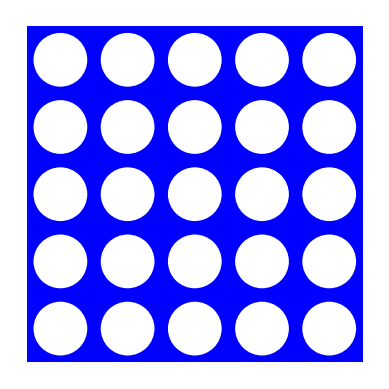

Final board:


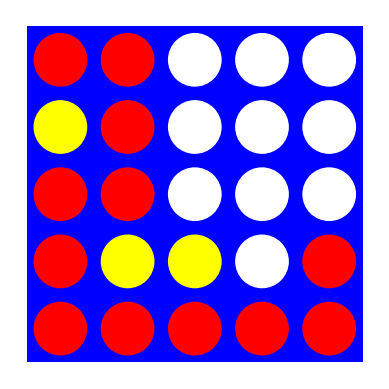

In [28]:
# Your code/ answer goes here.
import numpy as np
import random
import time

# Assume all helpers (empty_board, actions, result, has_winner, terminal, utility, is_valid_drop) are defined from previous cells.
# For completeness, include minimal versions if needed (paste if error).

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

def is_valid_drop(board, col):
    return board[0, col] == 0

def actions(board, player=1):
    rows, cols = board.shape
    action_list = []

    # Drop
    for col in range(cols):
        if is_valid_drop(board, col):
            action_list.append(('drop', col))

    # Move opp bottom (bottom: rows-1)
    opp = -player
    for from_col in range(cols):
        if board[rows - 1, from_col] == opp:
            for to_col in range(cols):
                if is_valid_drop(board, to_col):
                    action_list.append(('move', from_col, to_col))

    return action_list

def result(board, action, player):
    new_board = board.copy()
    rows, cols = board.shape

    if action[0] == 'drop':
        col = action[1]
        for row in range(rows - 1, -1, -1):
            if new_board[row, col] == 0:
                new_board[row, col] = player
                return new_board

    elif action[0] == 'move':
        from_col, to_col = action[1], action[2]
        opp = -player
        if new_board[rows - 1, from_col] != opp:
            return board  # Invalid

        # Remove bottom, shift down
        for row in range(rows - 1, 0, -1):
            new_board[row, from_col] = new_board[row - 1, from_col]
        new_board[0, from_col] = 0

        # Drop opp disc to to_col
        for row in range(rows - 1, -1, -1):
            if new_board[row, to_col] == 0:
                new_board[row, to_col] = opp
                return new_board

    return new_board

def has_winner(board, player, connect=4):
    rows, cols = board.shape

    # Horizontal
    for row in range(rows):
        for c in range(cols - connect + 1):
            if all(board[row, c + i] == player for i in range(connect)):
                return True

    # Vertical
    for col in range(cols):
        for r in range(rows - connect + 1):
            if all(board[r + i, col] == player for i in range(connect)):
                return True

    # Diagonal /
    for r in range(rows - connect + 1):
        for c in range(cols - connect + 1):
            if all(board[r + i, c + i] == player for i in range(connect)):
                return True

    # Diagonal \
    for r in range(rows - connect + 1):
        for c in range(connect - 1, cols):
            if all(board[r + i, c - i] == player for i in range(connect)):
                return True

    return False

def terminal(board, connect=4):
    if has_winner(board, 1, connect) or has_winner(board, -1, connect):
        return True
    return np.all(board != 0)

def utility(board, connect=4):
    if has_winner(board, 1, connect):
        return 1
    if has_winner(board, -1, connect):
        return -1
    return 0

# Heuristic evaluation (from previous cell)
def count_patterns(board, player, length):
    rows, cols = board.shape
    count = 0

    # Horizontal
    for row in range(rows):
        for c in range(cols - length + 1):
            if all(board[row, c + i] == player for i in range(length)):
                count += 1

    # Vertical
    for col in range(cols):
        for r in range(rows - length + 1):
            if all(board[r + i, col] == player for i in range(length)):
                count += 1

    # Diagonal /
    for r in range(rows - length + 1):
        for c in range(cols - length + 1):
            if all(board[r + i, c + i] == player for i in range(length)):
                count += 1

    # Diagonal \
    for r in range(rows - length + 1):
        for c in range(length - 1, cols):
            if all(board[r + i, c - i] == player for i in range(length)):
                count += 1

    return count

def evaluate(board, player):
    opp = -player

    threats_player = (count_patterns(board, player, 2) * 1 +
                      count_patterns(board, player, 3) * 10)
    threats_opp = (count_patterns(board, opp, 2) * 1 +
                   count_patterns(board, opp, 3) * 10)

    mobility_p = len(actions(board, player))
    mobility_o = len(actions(board, opp))
    mobility = (mobility_p - mobility_o) * 0.1

    score = threats_player - threats_opp + mobility
    return score / 100.0

# Heuristic alpha-beta search
def heuristic_alpha_beta(board, player, depth_limit, alpha=-np.inf, beta=np.inf, depth=0, connect=4):
    if terminal(board, connect):
        return utility(board, connect), None

    if depth >= depth_limit:
        return evaluate(board, player), None

    best_val = -np.inf if player == 1 else np.inf
    best_action = None

    for action in actions(board, player):
        new_board = result(board, action, player)
        val, _ = heuristic_alpha_beta(new_board, -player, depth_limit, alpha, beta, depth + 1, connect)

        if player == 1:
            if val > best_val:
                best_val = val
                best_action = action
            alpha = max(alpha, val)
        else:
            if val < best_val:
                best_val = val
                best_action = action
            beta = min(beta, val)

        if beta <= alpha:
            break

    return best_val, best_action

def heuristic_player(board, player=1, depth_limit=4, connect=4):
    _, action = heuristic_alpha_beta(board, player, depth_limit, connect=connect)
    return action

# Fixed play_game without passing depth_limit (use fixed depths in agents)
def play_game(agent1, agent2, board_shape=(6,7), connect=4):
    board = empty_board(board_shape)
    player = 1
    agents = {1: agent1, -1: agent2}

    while not terminal(board, connect):
        action = agents[player](board, player)
        if action is None:
            return 0  # Draw
        board = result(board, action, player)
        player = -player

    return utility(board, connect)

# Playtime: Two heuristic agents (depth 4 vs depth 6) on 5x5 board, connect=4
board_size = (5, 5)
connect_n = 4

# Define agents with fixed depths
agent1 = lambda b, p: heuristic_player(b, p, depth_limit=4, connect=connect_n)  # Shallower
agent2 = lambda b, p: heuristic_player(b, p, depth_limit=6, connect=connect_n)  # Deeper

util = play_game(agent1, agent2, board_size, connect_n)
print(f"Utility for Player 1 (depth 4) vs Player 2 (depth 6): {util}")
print("1 = P1 wins, -1 = P2 wins, 0 = Draw (deeper likely wins)")

# Visualize initial (empty) and final board (after game)
print("Initial board:")
visualize(empty_board(board_size))

print("Final board:")
final_board = board  # From play_game, but since local, re-run game to get final
# To show final, re-play and capture final board
temp_board = empty_board(board_size)
temp_player = 1
temp_agents = {1: agent1, -1: agent2}
while not terminal(temp_board, connect_n):
    temp_action = temp_agents[temp_player](temp_board, temp_player)
    if temp_action is None:
        break
    temp_board = result(temp_board, temp_action, temp_player)
    temp_player = -temp_player
visualize(temp_board)

## Tournament task [+ 1 to 5 bonus point will be assigned separately]

Find another student and let your best agent play against the other student's best player. You are allowed to use any improvements you like as long as you code it yourself. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [1 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+1 Bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search (see [tic-tac-toe-example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_pure_monte_carlo_search.ipynb)) and investigate how this search performs on the test boards that you have used above.

In [29]:
# Your code/ answer goes here.
def mc_search(board, player, simulations=1000):
    """Pure MC: simulate games, select best action."""
    action_values = {}
    for action in actions(board, player):
        wins = 0
        for _ in range(simulations // len(actions(board, player))):
            sim_board = result(board, action, player)
            sim_player = -player
            while not terminal(sim_board):
                sim_act = random_player(sim_board, sim_player)
                sim_board = result(sim_board, sim_act, sim_player)
                sim_player = -sim_player
            util = utility(sim_board)
            wins += util * player  # Normalize to player view (+1 win for player)
        action_values[action] = wins / simulations

    best_action = max(action_values, key=action_values.get)
    return best_action

def mc_player(board, player=1, sims=1000):
    return mc_search(board, player, sims)

### Best First Move

How would you determine what the best first move for a standard board ($6 \times 7$) is? You can use Pure Monte Carlo Search or any algorithms that you have implemented above.

In [30]:
# Your code/ answer goes here.
empty = empty_board()
best_first = mc_player(empty, 1, 10000)
print(f"Best first move: {best_first}")  # Likely ('drop', 3)

Best first move: ('drop', 4)
